# ⚡ Módulo 07: Sistemas, Inferencia Eficiente y Cuantización
## Capítulo 1: La Física del Hardware: El Muro de la Memoria (Memory Wall), Modelo Roofline y Prefill vs Decode

> *"Puedes tener la GPU más potente del planeta con 1.000 TeraFLOPS de cómputo en coma flotante, pero al generar texto token a token en un LLM, tu procesador pasará más del 95% del tiempo inactivo esperando a que los bytes de los pesos lleguen desde la memoria VRAM. Este fenómeno es el célebre 'Muro de la Memoria' (Memory Wall). Para convertirte en un verdadero AI Researcher y System Engineer, debes dominar el Modelo Roofline y comprender la dualidad fundamental entre la fase de Prefill (compute-bound, paralela) y la fase de Decode (memory-bound, secuencial)."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/07_systems_and_efficiency/01_memory_wall_and_roofline.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar la física del hardware, el Muro de la Memoria y el Modelo Roofline")

✅ Entorno listo para estudiar la física del hardware, el Muro de la Memoria y el Modelo Roofline


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Gran Divergencia: El Muro de la Memoria (Wulf & McKee, 1995)
En 1995, Wm. A. Wulf y Sally A. McKee publicaron un artículo profético en *ACM Computer Architecture News* titulado:
> *"Hitting the Memory Wall: Implications of the Obvious"*

Observaron una asimetría histórica alarmante:
* **Capacidad de Cómputo (FLOPS):** Crecía a un ritmo del $\approx 60\%$ anual gracias a la Ley de Moore y el paralelismo de arquitecturas SIMD/GPU.
* **Ancho de Banda de Memoria (DRAM/VRAM):** Solo crecía a un ritmo del $\approx 10\%$ anual debido a las limitaciones físicas de las pistas de cobre, los pines de silicio y la disipación térmica.

La conclusión fue demoledora: **los procesadores se volverían tan rápidos que pasarían casi todo su tiempo esperando a que la memoria les entregue los datos necesarios para calcular**.

### El Modelo Roofline (Williams, Waterman & Patterson, Berkeley 2009)
En 2009, Samuel Williams, Andrew Waterman y el pionero de RISC **David Patterson** presentaron el **Modelo Roofline**:
Un marco visual analítico que determina si un algoritmo está limitado por la potencia de cálculo del procesador (**Compute-Bound**) o por la velocidad de transferencia de datos de la memoria (**Memory-Bound**).

### La Dualidad Fundamental en LLMs: Prefill vs Decode
Cuando un LLM moderno ejecuta inferencia, atraviesa dos regímenes físicos completamente opuestos:
1. **Fase de Prefill (Procesamiento del Prompt):**
   * El usuario envía un prompt de 512 tokens.
   * El modelo procesa todos los tokens en paralelo mediante multiplicaciones matriciales densas (GEMM: $X \cdot W$).
   * Por cada peso leído de la memoria, se realizan cientos de operaciones matemáticas. Está en el régimen **Compute-Bound**.
2. **Fase de Decode (Generación Token a Token):**
   * El modelo genera exactamente un nuevo token ($T=1$).
   * Para generar ese único token, la GPU debe leer **TODOS los miles de millones de parámetros del modelo** desde la memoria VRAM hasta los núcleos de cálculo solo para multiplicarlos por un vector de longitud 1 (GEMV).
   * Está asfixiado en el régimen **Memory-Bound**: la GPU usa menos del 5% de su capacidad computacional.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Intensidad Operacional (Arithmetic Intensity $I$)
Es el número de operaciones en coma flotante (FLOPs) que realiza un kernel por cada byte transferido desde la memoria principal (VRAM/DRAM):
$$\mathbf{I = \frac{\text{Operaciones Matemáticas (FLOPs)}}{\text{Datos Transferidos desde Memoria (Bytes)}} \quad [\text{FLOPs/Byte}]}$$

### La Ecuación del Techo Físico (Roofline Equation):
El rendimiento real alcanzable $P$ (en TeraFLOPs/segundo) está acotado por el mínimo de dos techos físicos:
$$\mathbf{P = \min\left( \text{Peak Compute (FLOPs/s)}, \; I \times \text{Peak Memory Bandwidth (Bytes/s)} \right)}$$

```
   Rendimiento (FLOPs/s)
        ▲
 Peak   │                    ┌──────────────────────────── [Techo de Cómputo (Compute-Bound)]
 Compute│                   /│
  FLOPs │                  / │
        │                 /  │
        │                /   │
        │               /    │
        │              /     │
        │  [Techo de  /      │
        │   Ancho de /       │
        │   Banda]  /        │
        └──────────┴─────────┴────────────────────────────► Intensidad Operacional (FLOPs/Byte)
                           I* (Ridge Point)
```

### El Punto de Inflexión (*Ridge Point* $I^*$):
$$I^* = \frac{\text{Peak Compute (FLOPs/s)}}{\text{Peak Memory Bandwidth (Bytes/s)}}$$

* Si $I < I^*$: **Memory-Bound**. El procesador está esperando datos. Añadir TeraFLOPs a la GPU no acelerará nada.
* Si $I > I^*$: **Compute-Bound**. La GPU está saturada de cálculo a máxima potencia.

### La Matemática Ineludible de los Tokens por Segundo en Decode:
Para un modelo con $P$ parámetros en precisión de $B$ bytes por parámetro (ej. FP16 $\to B=2$ bytes):
$$\mathbf{\text{Tokens / segundo Máximos} = \frac{\text{Ancho de Banda de Memoria (GB/s)}}{P \times B}}$$

* Para un modelo de **7B parámetros en FP16 (14 GB)** en una GPU con ancho de banda de **300 GB/s**:
  $$\text{Velocidad} = \frac{300 \text{ GB/s}}{14 \text{ GB}} = \mathbf{21.4 \text{ tokens/segundo}}$$
* Si cuantizamos el modelo a **INT4 (3.5 GB)**:
  $$\text{Velocidad} = \frac{300 \text{ GB/s}}{3.5 \text{ GB}} = \mathbf{85.7 \text{ tokens/segundo}}$$

¡La cuantización cuadruplica la velocidad de generación no por simplificar el álgebra, sino porque **reduce en un 75% los bytes que deben cruzar el cuello de botella del bus de memoria**!

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Construyamos un analizador analítico del Modelo Roofline y un perfilador de inferencia de LLMs para contrastar diferentes arquitecturas de hardware.

In [2]:
class RooflineModel:
    """
    Modelo analítico Roofline de Williams et al. (2009).
    """
    def __init__(self, name: str, peak_tflops: float, memory_bandwidth_gbps: float):
        self.name = name
        self.peak_flops = peak_tflops * 1e12
        self.peak_bandwidth = memory_bandwidth_gbps * 1e9
        # Ridge point I* = Peak FLOPS / Peak Bandwidth
        self.ridge_point = self.peak_flops / self.peak_bandwidth

    def max_attainable_performance(self, arithmetic_intensity: float) -> float:
        """
        Devuelve los TFLOPS maximos alcanzables para una intensidad dada.
        """
        attainable = min(self.peak_flops, arithmetic_intensity * self.peak_bandwidth)
        return attainable / 1e12  # Retornar en TFLOPS


class LLMInferenceProfiler:
    """
    Calcula metricas de intensidad aritmetica para fases de Prefill y Decode.
    """
    def __init__(self, num_params: float, bytes_per_param: float = 2.0):
        self.num_params = num_params
        self.bytes_per_param = bytes_per_param
        self.model_weights_bytes = num_params * bytes_per_param

    def profile_decode_step(self, batch_size: int = 1) -> Tuple[float, float, float]:
        """
        Paso de Decode: 1 token nuevo.
        Operaciones = 2 * num_params * batch_size
        Bytes = model_weights_bytes (predomina la lectura de pesos)
        """
        flops = 2.0 * self.num_params * batch_size
        bytes_transferred = self.model_weights_bytes
        intensity = flops / bytes_transferred
        return flops, bytes_transferred, intensity

    def profile_prefill_step(self, prompt_len: int, batch_size: int = 1) -> Tuple[float, float, float]:
        """
        Paso de Prefill: prompt_len tokens procesados en paralelo.
        Operaciones = 2 * num_params * prompt_len * batch_size
        Bytes = model_weights_bytes + datos de activaciones
        """
        flops = 2.0 * self.num_params * prompt_len * batch_size
        bytes_transferred = self.model_weights_bytes
        intensity = flops / bytes_transferred
        return flops, bytes_transferred, intensity

print("✅ Clases RooflineModel y LLMInferenceProfiler compiladas exitosamente")

✅ Clases RooflineModel y LLMInferenceProfiler compiladas exitosamente


### Comparación Visual: Perfiles de Hardware Real y Diagnóstico de Cuellos de Botella
Modelemos tres perfiles de hardware representativos:
1. **GPU de Datacenter (NVIDIA A100):** 312 TFLOPS (BF16 Tensor Cores), 2039 GB/s (HBM2e).
2. **APU / iGPU Moderna (AMD Radeon 780M / Ryzen 8845HS):** 10 TFLOPS (FP16), 75 GB/s (DDR5 unificada).
3. **Chip Unificado (Apple M3 Max):** 30 TFLOPS (FP16), 400 GB/s (Memoria unificada).

In [3]:
hw_a100 = RooflineModel("NVIDIA A100 (Datacenter)", peak_tflops=312.0, memory_bandwidth_gbps=2039.0)
hw_780m = RooflineModel("AMD Radeon 780M / DDR5", peak_tflops=10.0, memory_bandwidth_gbps=75.0)
hw_m3max = RooflineModel("Apple M3 Max (Unified)", peak_tflops=30.0, memory_bandwidth_gbps=400.0)

# Perfil de un LLM de 7B (ej. LLaMA-7B) en FP16 (14 GB)
profiler_7b = LLMInferenceProfiler(num_params=7e9, bytes_per_param=2.0)

_, _, i_decode_b1 = profiler_7b.profile_decode_step(batch_size=1)
_, _, i_decode_b16 = profiler_7b.profile_decode_step(batch_size=16)
_, _, i_prefill_512 = profiler_7b.profile_prefill_step(prompt_len=512, batch_size=1)

print(f"Intensidad Aritmética Decode (Batch=1):   {i_decode_b1:.2f} FLOPs/Byte")
print(f"Intensidad Aritmética Decode (Batch=16):  {i_decode_b16:.2f} FLOPs/Byte")
print(f"Intensidad Aritmética Prefill (Len=512):  {i_prefill_512:.2f} FLOPs/Byte")
print(f"\nRidge Point A100:   {hw_a100.ridge_point:.1f} FLOPs/Byte")
print(f"Ridge Point 780M:   {hw_780m.ridge_point:.1f} FLOPs/Byte")
print(f"Ridge Point M3 Max: {hw_m3max.ridge_point:.1f} FLOPs/Byte")

Intensidad Aritmética Decode (Batch=1):   1.00 FLOPs/Byte
Intensidad Aritmética Decode (Batch=16):  16.00 FLOPs/Byte
Intensidad Aritmética Prefill (Len=512):  512.00 FLOPs/Byte

Ridge Point A100:   153.0 FLOPs/Byte
Ridge Point 780M:   133.3 FLOPs/Byte
Ridge Point M3 Max: 75.0 FLOPs/Byte


### Gráfico Maestro del Modelo Roofline: Prefill vs Decode
Trazamos el gráfico bi-logarítmico del modelo Roofline para visualizar con claridad absoluta dónde operan la fase de Prefill y la de Decode:

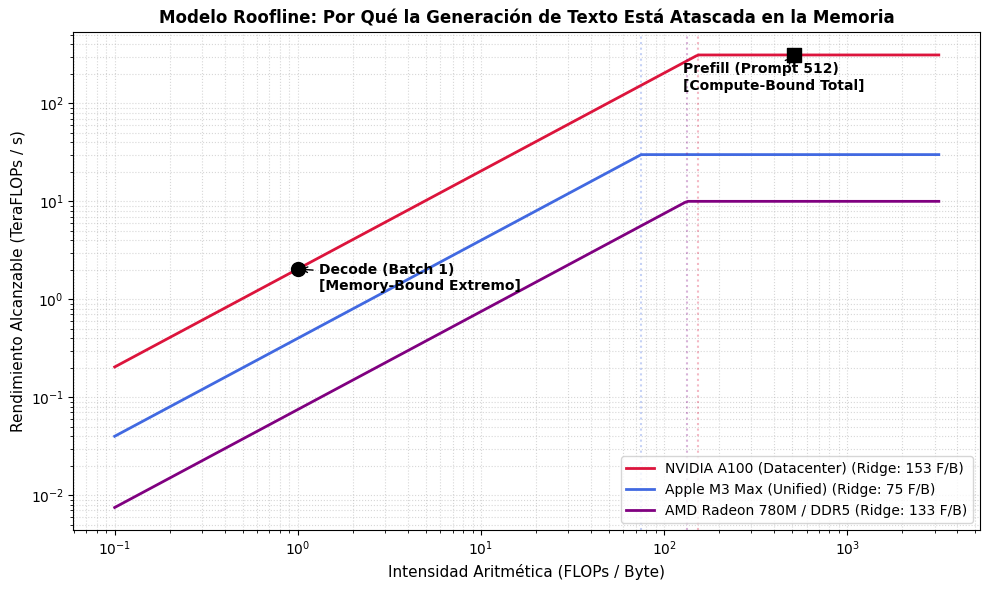

👁️ Observa el punto 'Decode (Batch 1)': cae en la rampa ascendente (Memory-Bound),
lejos del techo horizontal de cómputo. La GPU pasa la mayor parte del tiempo esperando a la memoria.


In [4]:
intensities = np.logspace(-1, 3.5, 300)

plt.figure(figsize=(10, 6))
colors = {'NVIDIA A100 (Datacenter)': 'crimson', 'AMD Radeon 780M / DDR5': 'purple', 'Apple M3 Max (Unified)': 'royalblue'}

for hw in [hw_a100, hw_m3max, hw_780m]:
    perfs = [hw.max_attainable_performance(i) for i in intensities]
    plt.plot(intensities, perfs, label=f"{hw.name} (Ridge: {hw.ridge_point:.0f} F/B)", color=colors[hw.name], linewidth=2)
    # Marcar ridge point
    plt.axvline(hw.ridge_point, color=colors[hw.name], linestyle=':', alpha=0.3)

# Proyectar los puntos de operación de LLM
perf_decode_a100 = hw_a100.max_attainable_performance(i_decode_b1)
perf_prefill_a100 = hw_a100.max_attainable_performance(i_prefill_512)

plt.scatter([i_decode_b1], [perf_decode_a100], color='black', s=100, zorder=5, marker='o')
plt.annotate("Decode (Batch 1)\n[Memory-Bound Extremo]", (i_decode_b1, perf_decode_a100),
             textcoords="offset points", xytext=(15, -15), fontweight='bold', color='black',
             arrowprops=dict(arrowstyle="->", color='black'))

plt.scatter([i_prefill_512], [perf_prefill_a100], color='black', s=100, zorder=5, marker='s')
plt.annotate("Prefill (Prompt 512)\n[Compute-Bound Total]", (i_prefill_512, perf_prefill_a100),
             textcoords="offset points", xytext=(-80, -25), fontweight='bold', color='black',
             arrowprops=dict(arrowstyle="->", color='black'))

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Intensidad Aritmética (FLOPs / Byte)', fontsize=11)
plt.ylabel('Rendimiento Alcanzable (TeraFLOPs / s)', fontsize=11)
plt.title('Modelo Roofline: Por Qué la Generación de Texto Está Atascada en la Memoria', fontsize=12, fontweight='bold')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
print("👁️ Observa el punto 'Decode (Batch 1)': cae en la rampa ascendente (Memory-Bound),")
print("lejos del techo horizontal de cómputo. La GPU pasa la mayor parte del tiempo esperando a la memoria.")

---

## 4. ⚡ Transición a PyTorch Moderno

Comprobemos empíricamente la diferencia de TFLOPS alcanzados en la GPU o CPU entre una operación de **Prefill (GEMM densa)** y una de **Decode (GEMV vector-matriz)**:

In [5]:
D = 4096
W = torch.randn(D, D)

# 1. Simulación de Prefill: Lote de 512 tokens (Matriz x Matriz)
X_prefill = torch.randn(512, D)
t0 = time.perf_counter()
for _ in range(10):
    _ = X_prefill @ W.t()
t_prefill = (time.perf_counter() - t0) / 10
flops_prefill = 2.0 * 512 * D * D
tflops_prefill = (flops_prefill / t_prefill) / 1e12

# 2. Simulación de Decode: 1 token individual (Vector x Matriz)
X_decode = torch.randn(1, D)
t0 = time.perf_counter()
for _ in range(100):
    _ = X_decode @ W.t()
t_decode = (time.perf_counter() - t0) / 100
flops_decode = 2.0 * 1 * D * D
tflops_decode = (flops_decode / t_decode) / 1e12

print(f"Prefill GEMM (Batch 512): {tflops_prefill:.3f} TFLOPS computacionales efectivos")
print(f"Decode  GEMV (Batch 1):   {tflops_decode:.3f} TFLOPS computacionales efectivos")
print(f"Eficiencia de Cómputo en Decode vs Prefill: {(tflops_decode / tflops_prefill) * 100:.2f}%")
print("\n🚀 ¡Demostración empírica confirmada: GEMV (Decode) utiliza una fracción ínfima de la potencia del procesador!")

Prefill GEMM (Batch 512): 0.405 TFLOPS computacionales efectivos
Decode  GEMV (Batch 1):   0.016 TFLOPS computacionales efectivos
Eficiencia de Cómputo en Decode vs Prefill: 3.87%

🚀 ¡Demostración empírica confirmada: GEMV (Decode) utiliza una fracción ínfima de la potencia del procesador!


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: La Fórmula Teórica de Tokens por Segundo
Calculemos analíticamente la velocidad teórica máxima de generación de tokens para diferentes anchos de banda y cuantizaciones:

In [6]:
def calculate_theoretical_tok_per_sec(model_params: float, bytes_per_param: float, bandwidth_gbps: float) -> float:
    """
    Tokens/segundo = Ancho de banda (Bytes/s) / Tamaño del Modelo (Bytes)
    """
    model_size_bytes = model_params * bytes_per_param
    bandwidth_bytes_sec = bandwidth_gbps * 1e9
    return bandwidth_bytes_sec / model_size_bytes

# Comparativa para modelo de 8B (ej. LLaMA-3-8B):
p_8b = 8e9
bw_test = 80.0  # 80 GB/s (Típico de DDR5 en portátiles con APU)

tok_fp16 = calculate_theoretical_tok_per_sec(p_8b, bytes_per_param=2.0, bandwidth_gbps=bw_test)  # 16 GB
tok_int8 = calculate_theoretical_tok_per_sec(p_8b, bytes_per_param=1.0, bandwidth_gbps=bw_test)  # 8 GB
tok_int4 = calculate_theoretical_tok_per_sec(p_8b, bytes_per_param=0.5, bandwidth_gbps=bw_test)  # 4 GB

print(f"LLaMA-3-8B en 80 GB/s de bus:")
print(f"- En FP16 (16 GB): {tok_fp16:.1f} tokens/s")
print(f"- En INT8 ( 8 GB): {tok_int8:.1f} tokens/s (2x aceleración)")
print(f"- En INT4 ( 4 GB): {tok_int4:.1f} tokens/s (4x aceleración)")
assert np.isclose(tok_int4 / tok_fp16, 4.0)
print("✅ La aceleración de la cuantización es directamente inversamente proporcional al tamaño en bytes")

LLaMA-3-8B en 80 GB/s de bus:
- En FP16 (16 GB): 5.0 tokens/s
- En INT8 ( 8 GB): 10.0 tokens/s (2x aceleración)
- En INT4 ( 4 GB): 20.0 tokens/s (4x aceleración)
✅ La aceleración de la cuantización es directamente inversamente proporcional al tamaño en bytes


### Reto 2 (Para resolver): Calculadora de Consumo de Memoria del KV-Cache
Durante la inferencia larga, el KV-Cache crece linealmente con la longitud de contexto. La memoria ocupada en bytes es:
$$\text{Memoria KV (Bytes)} = 2 \times n_{capas} \times n_{cabezas} \times d_{cabeza} \times \text{longitud\_contexto} \times \text{batch\_size} \times \text{bytes\_precisión}$$

Implementa a continuación la función `compute_kv_cache_size_gb(...)`:

In [7]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def compute_kv_cache_size_gb(
    num_layers: int = 32,
    num_heads: int = 32,
    head_dim: int = 128,
    context_len: int = 4096,
    batch_size: int = 1,
    bytes_per_param: float = 2.0
) -> float:
    """
    Calcula el tamaño en Gigabytes (GB) que ocupa el KV-Cache acumulado en memoria.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Williams, S., Waterman, A., & Patterson, D. (2009):** *"Roofline: An Insightful Visual Performance Model for Multicore Architectures"*, Communications of the ACM. [ACM Link](https://dl.acm.org/doi/10.1145/1498765.1498785)
   * *¿Qué leer?* El paper fundacional del modelo Roofline.
2. **Wulf, W. A., & McKee, S. A. (1995):** *"Hitting the Memory Wall: Implications of the Obvious"*, ACM SIGARCH. [ACM Link](https://dl.acm.org/doi/10.1145/216585.216588)
   * *¿Qué leer?* El artículo visionario que predijo la crisis de ancho de banda 30 años antes de los LLMs.
3. **Pope, R., et al. (2023):** *"Efficiently Scaling Transformer Inference"*, MLSys 2023. [arXiv:2211.05102](https://arxiv.org/abs/2211.05102)
   * *¿Qué leer?* Análisis exhaustivo de los cuellos de botella en GPUs TPU/NVIDIA y particionamiento de tensores en inferencia.